# Retail Sales Forecasting

Prediction of weekly retail sales using machine learning techniques on the Walmart dataset.

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

## 2. Data Loading

In [3]:
data_path = "data/"

train = pd.read_csv(data_path + "train.csv")
stores = pd.read_csv(data_path + "stores.csv")
features = pd.read_csv(data_path + "features.csv")

The dataset consists of:
- **train**: historical weekly sales data
- **stores**: store metadata
- **features**: external factors (temperature, CPI, holidays)

## 3. Data Cleaning

In [4]:
df = train.merge(stores, on="Store", how="left")
df = df.merge(features, on=["Store", "Date", "IsHoliday"], how="left")

df["Date"] = pd.to_datetime(df["Date"])

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.head(10)

MarkDown2      310322
MarkDown4      286603
MarkDown3      284479
MarkDown1      270889
MarkDown5      270138
Store               0
Date                0
Dept                0
Temperature         0
Size                0
dtype: int64

## 4. Exploratory Data Analysis

Exploratory data analysis was conducted to understand sales patterns, seasonality, and key business drivers.

### Weekly Sales Trend

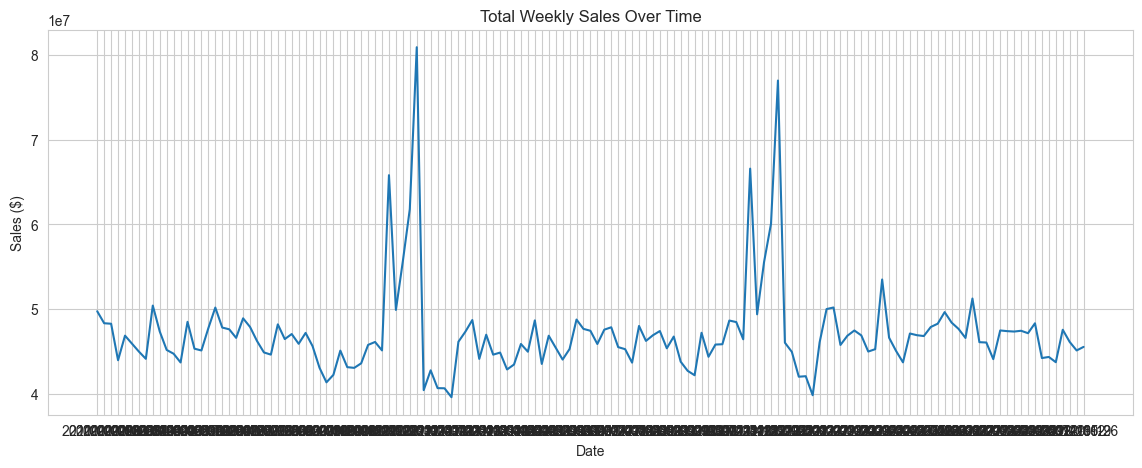

In [5]:
weekly_sales = train.groupby("Date")["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(weekly_sales["Date"], weekly_sales["Weekly_Sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.show()

### Holiday vs Non-Holiday Sales

In [6]:
train.groupby("IsHoliday")["Weekly_Sales"].mean()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

### Monthly Sales Seasonality

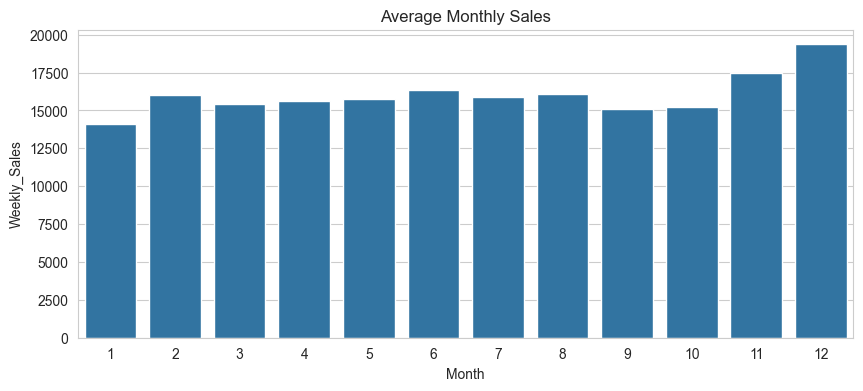

In [7]:
train["Month"] = pd.to_datetime(train["Date"]).dt.month

monthly = train.groupby("Month")["Weekly_Sales"].mean().reset_index()

plt.figure(figsize=(10,4))
sns.barplot(data=monthly, x="Month", y="Weekly_Sales")
plt.title("Average Monthly Sales")
plt.show()

### Top Performing Stores

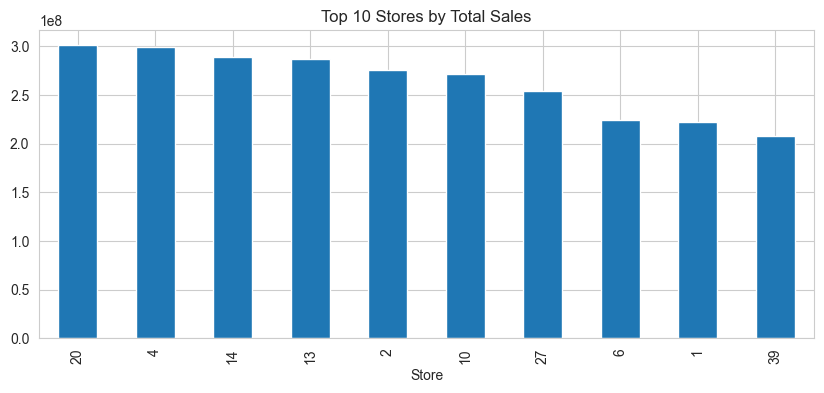

In [8]:
top_stores = train.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,4))
top_stores.plot(kind="bar")
plt.title("Top 10 Stores by Total Sales")
plt.show()

## 5. Feature Engineering

New features were created to capture time dependencies and seasonality.

In [9]:
df = df.sort_values(["Store", "Dept", "Date"])

df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

# Lag features
df["Sales_Lag_1"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(1)
df["Sales_Lag_2"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(2)
df["Sales_Lag_4"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(4)

# Rolling mean
df["Sales_RollingMean_4"] = df.groupby(["Store","Dept"])["Weekly_Sales"]\
    .transform(lambda x: x.shift(1).rolling(4).mean())

# Fill markdowns
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
df[markdown_cols] = df[markdown_cols].fillna(0)

# Encode store type
df["Type_Encoded"] = df["Type"].map({"A":0,"B":1,"C":2})

df["IsHoliday"] = df["IsHoliday"].astype(int)

## 6. Modeling

A Random Forest model was used with a time-based split.

In [10]:
FEATURES = [
    "Store","Dept","IsHoliday","Month","Year","WeekOfYear",
    "Type_Encoded","Size",
    "MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5",
    "Temperature","Fuel_Price","CPI","Unemployment",
    "Sales_Lag_1","Sales_Lag_2","Sales_Lag_4","Sales_RollingMean_4"
]

TARGET = "Weekly_Sales"

df_model = df[FEATURES + [TARGET,"Date"]].dropna()

train_df = df_model[df_model["Date"] < "2012-01-01"]
test_df = df_model[df_model["Date"] >= "2012-01-01"]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 7. Evaluation

In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

mae, rmse, mape

(1577.3588778751885, np.float64(3364.9626198405845), np.float64(inf))

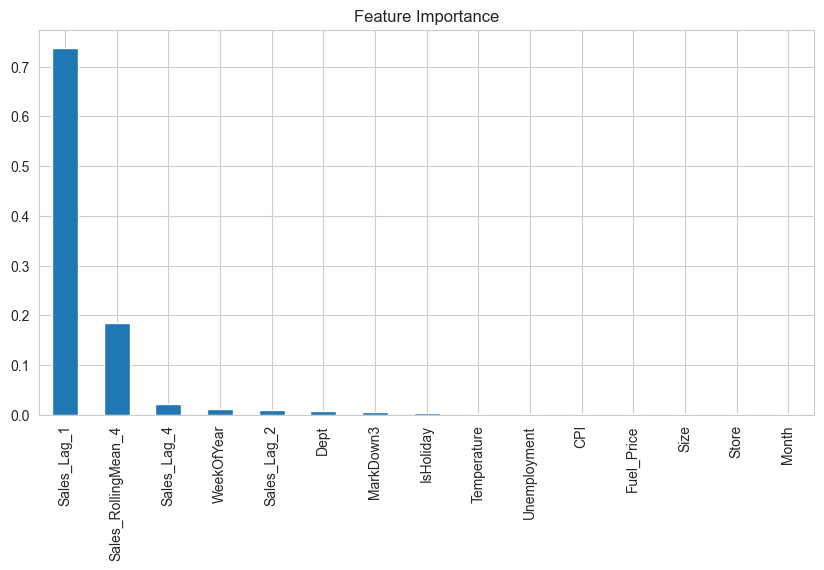

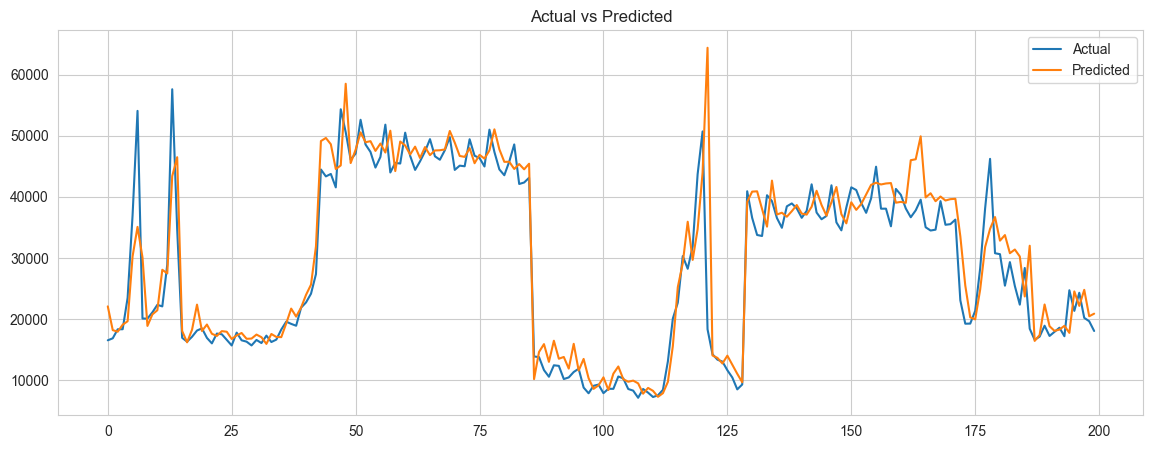

In [12]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.head(15).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

## 8. Conclusion

The Random Forest model achieved strong performance in forecasting weekly retail sales.

Key findings:
- Sales show clear seasonality patterns
- Lag features significantly improve predictions
- Store characteristics and external factors impact performance

Future work:
- Hyperparameter tuning
- Testing advanced models (XGBoost, LSTM)